In [1]:
import sys
from pathlib import Path
import numpy as np
import torch
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding

# Setup paths (basato sul tuo script precedente)
ROOT = Path.cwd().resolve().parent
if str(ROOT / "src") not in sys.path:
    sys.path.append(str(ROOT / "src"))

from project_paths import get_paths
paths = get_paths(ROOT)
DATA_DIR = paths.data_processed
CKPT_DIR = paths.checkpoints

print("ROOT:", ROOT)
print("DATA_DIR:", DATA_DIR)
print("CKPT_DIR:", CKPT_DIR)

c:\Users\cola0\anaconda3\envs\nlp-project\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ROOT: C:\Users\cola0\Desktop\nlp.project-colangelo-2526
DATA_DIR: C:\Users\cola0\Desktop\nlp.project-colangelo-2526\data\processed
CKPT_DIR: C:\Users\cola0\Desktop\nlp.project-colangelo-2526\checkpoints


In [2]:
# === Checkpoint paths ===
# Teacher fine-tuned
teacher_path = CKPT_DIR / "bert_teacher_finetuned" / "checkpoint-18000"

# IMPORTANT:
# Per la fase 1 NON usare 'student_base_final' (salva solo il backbone HF).
# Devi usare un checkpoint del Trainer (checkpoint-xxxxx) che contiene anche i pesi di 'fit_dense'.
phase1_ckpt_path = CKPT_DIR / "tinybert_phase1" / "checkpoint-57856"  # <-- ultimo checkpoint
student_core_path = CKPT_DIR / "tinybert_phase1" / "student_base_final"

# (Opzionale) student fase 2, se vuoi confrontare anche quello
student_phase2_path = CKPT_DIR / "tinybert_phase2" / "checkpoint-13000"

print("Teacher:", teacher_path)
print("Phase1 ckpt (con fit_dense):", phase1_ckpt_path)
print("Student phase2 (opzionale):", student_phase2_path)

assert teacher_path.exists(), f"Non esiste: {teacher_path}"
assert phase1_ckpt_path.exists(), f"Non esiste: {phase1_ckpt_path}"


Teacher: C:\Users\cola0\Desktop\nlp.project-colangelo-2526\checkpoints\bert_teacher_finetuned\checkpoint-18000
Phase1 ckpt (con fit_dense): C:\Users\cola0\Desktop\nlp.project-colangelo-2526\checkpoints\tinybert_phase1\checkpoint-57856
Student phase2 (opzionale): C:\Users\cola0\Desktop\nlp.project-colangelo-2526\checkpoints\tinybert_phase2\checkpoint-13000


## Plot 3: PCA only

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased", use_fast=True)

teacher = AutoModelForSequenceClassification.from_pretrained(teacher_path).to(device).eval()

# core HF (student backbone) dal checkpoint fase 1
student_core = AutoModelForSequenceClassification.from_pretrained(phase1_ckpt_path).to(device).eval()


Device: cuda


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at C:\Users\cola0\Desktop\nlp.project-colangelo-2526\checkpoints\tinybert_phase1\checkpoint-57856 and are newly initialized: ['bert.embeddings.LayerNorm.bias', 'bert.embeddings.LayerNorm.weight', 'bert.embeddings.position_embeddings.weight', 'bert.embeddings.token_type_embeddings.weight', 'bert.embeddings.word_embeddings.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.dense.bias', 'bert.encoder.layer.0.attention.output.dense.weight', 'bert.encoder.layer.0.attention.self.key.bias', 'bert.encoder.layer.0.attention.self.key.weight', 'bert.encoder.layer.0.attention.self.query.bias', 'bert.encoder.layer.0.attention.self.query.weight', 'bert.encoder.layer.0.attention.self.value.bias', 'bert.encoder.layer.0.attention.self.value.weight', 'bert.encoder.layer.0.intermediate.dense.bias', 'bert

In [4]:
import torch
from safetensors.torch import load_file
from transformers import AutoModelForSequenceClassification
from distillation import TinyBERTPhase1

device = "cuda" if torch.cuda.is_available() else "cpu"

# path
#student_core_path = "checkpoints/tinybert_phase1/student_base_final"     # ha config 312
#phase1_ckpt_path   = "checkpoints/tinybert_phase1/checkpoint-57856"      # ha wrapper weights incl fit_dense

# 1) Crea core corretto (hidden_size=312)
student_core = AutoModelForSequenceClassification.from_pretrained(student_core_path).to(device).eval()

# 2) Wrappa
student = TinyBERTPhase1(student_core).to(device).eval()

# 3) Carica state dict del trainer checkpoint, ma:
#    - dentro ci sono chiavi "student.*" e "fit_dense.*"
sd = load_file(f"{phase1_ckpt_path}/model.safetensors")

# 4) Carica direttamente: deve andare senza mismatch ora
missing, unexpected = student.load_state_dict(sd, strict=False)

print("Missing fit_dense keys:", [k for k in missing if "fit_dense" in k])
print("Unexpected keys (sample):", unexpected[:15])

Missing fit_dense keys: []
Unexpected keys (sample): []


In [5]:
mapping = [0, 3, 6, 9, 12]
student_last_idx = 4
teacher_last_idx = 12

def mean_pool(hidden, attention_mask):
    # hidden: [1,L,H], attention_mask: [1,L]
    mask = attention_mask.unsqueeze(-1).to(hidden.dtype)  # [1,L,1]
    summed = (hidden * mask).sum(dim=1)
    denom = mask.sum(dim=1).clamp(min=1.0)
    return summed / denom  # [1,H]

@torch.no_grad()
def collect_reps(test_ds, n_samples=2000, seed=0, pooling="mean"):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(test_ds), size=min(n_samples, len(test_ds)), replace=False)

    T_vecs, S_vecs, y = [], [], []

    for i in idx:
        ex = test_ds[i]
        input_ids = torch.tensor(ex["input_ids"]).unsqueeze(0).to(device)
        attention_mask = torch.tensor(ex["attention_mask"]).unsqueeze(0).to(device)
        token_type_ids = torch.tensor(ex["token_type_ids"]).unsqueeze(0).to(device) if "token_type_ids" in ex else None

        t_out = teacher(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            output_hidden_states=True,
            return_dict=True
        )
        s_out = student(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
        )

        # teacher hidden: len=13, idx 12 = last layer
        t_h = t_out.hidden_states[teacher_last_idx]  # [1,L,768]

        # student hidden: len=5, idx 4 = last layer (312) -> proiezione in 768 con fit_dense addestrata
        s_h = s_out.hidden_states[student_last_idx]              # [1,L,312]
        s_proj = student.fit_dense[student_last_idx](s_h)        # [1,L,768]

        if pooling == "cls":
            t_vec = t_h[:, 0, :]
            s_vec = s_proj[:, 0, :]
        elif pooling == "mean":
            t_vec = mean_pool(t_h, attention_mask)
            s_vec = mean_pool(s_proj, attention_mask)
        else:
            raise ValueError("pooling deve essere 'cls' oppure 'mean'")

        T_vecs.append(t_vec.squeeze(0).cpu().numpy())
        S_vecs.append(s_vec.squeeze(0).cpu().numpy())
        y.append(int(ex["label"]))

    return np.vstack(T_vecs), np.vstack(S_vecs), np.array(y)

# Carico test set
from datasets import concatenate_datasets

test_ds = load_dataset("parquet", data_files=str(DATA_DIR / "test.parquet"))["train"]

N_PER_CLASS = 2000
SEED = 42

ds0 = test_ds.filter(lambda x: x["label"] == 0).shuffle(seed=SEED).select(range(N_PER_CLASS))
ds1 = test_ds.filter(lambda x: x["label"] == 1).shuffle(seed=SEED).select(range(N_PER_CLASS))

test_balanced = concatenate_datasets([ds0, ds1]).shuffle(seed=SEED)
print(test_balanced, test_balanced.features)
# Consigliato: mean pooling (più stabile di CLS per confronti di alignment)
T, S, y = collect_reps(test_balanced, n_samples=2000, pooling="mean")


Generating train split: 9925 examples [00:00, 31900.99 examples/s]
Filter: 100%|██████████| 9925/9925 [00:04<00:00, 2358.07 examples/s]


Dataset({
    features: ['review_id', 'movie_id', 'text', 'label', 'input_ids', 'attention_mask', 'token_type_ids'],
    num_rows: 4000
}) {'review_id': Value('int64'), 'movie_id': Value('string'), 'text': Value('string'), 'label': Value('int64'), 'input_ids': List(Value('int64')), 'attention_mask': List(Value('int64')), 'token_type_ids': List(Value('int64'))}


BertSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


In [6]:
# === PCA 3D in "teacher space" ===
# Fit scaler + PCA SOLO sul teacher, poi proietta anche lo student nello stesso spazio.

scaler = StandardScaler().fit(T)
Tz = scaler.transform(T)
Sz = scaler.transform(S)

pca = PCA(n_components=3, random_state=0)
pca.fit(Tz)          # <-- fit solo teacher
T3 = pca.transform(Tz)
S3 = pca.transform(Sz)


In [7]:
def cosine(a, b, eps=1e-9):
    a = a / (np.linalg.norm(a, axis=1, keepdims=True) + eps)
    b = b / (np.linalg.norm(b, axis=1, keepdims=True) + eps)
    return (a * b).sum(axis=1)

cos_sim = cosine(S, T)

print("Mean cosine (No-spoiler):", float(cos_sim[y==0].mean()), "±", float(cos_sim[y==0].std()))
print("Mean cosine (Spoiler):   ", float(cos_sim[y==1].mean()), "±", float(cos_sim[y==1].std()))


Mean cosine (No-spoiler): 0.964600682258606 ± 0.019438542425632477
Mean cosine (Spoiler):    0.9617341160774231 ± 0.025829210877418518


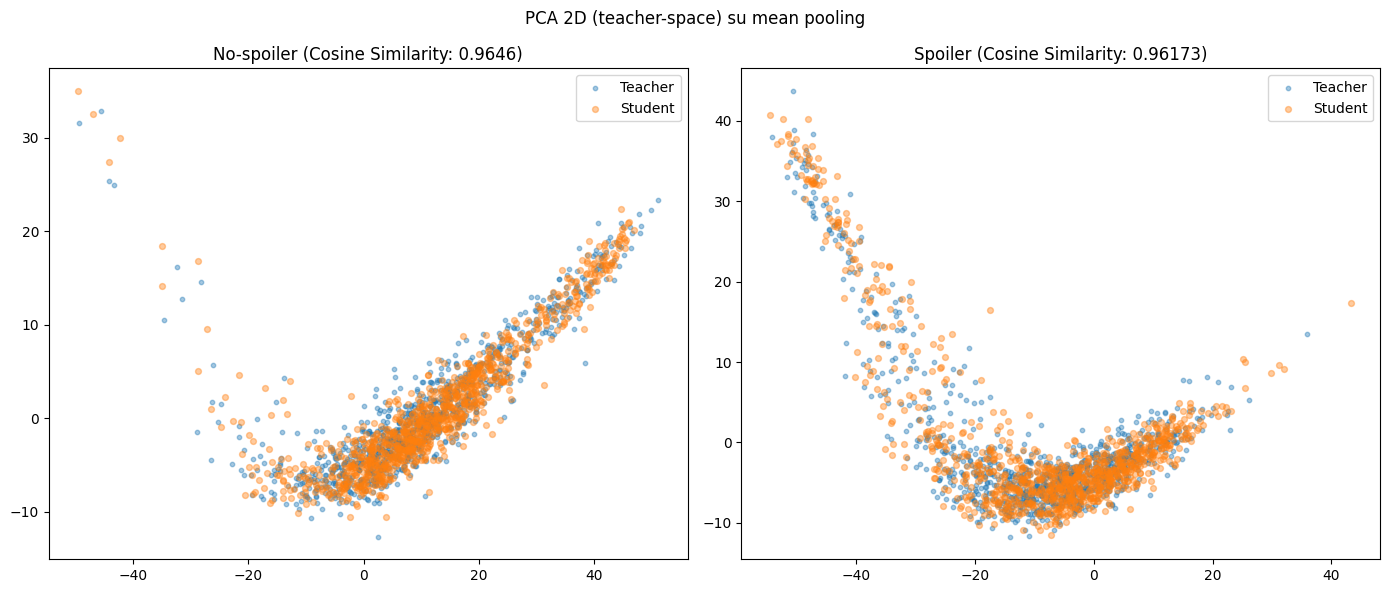

<Figure size 640x480 with 0 Axes>

In [9]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# X teacher-space già costruito: T (N,768), S (N,768), y (N,)
# PCA fit sul teacher
Tz = StandardScaler().fit_transform(T)
pca = PCA(n_components=2, random_state=0).fit(Tz)

T2 = pca.transform(Tz)
S2 = pca.transform(StandardScaler().fit_transform(S))  # meglio: usa lo stesso scaler del teacher!
# -> versione corretta:
scaler = StandardScaler().fit(T)
T2 = pca.fit_transform(scaler.transform(T))
S2 = pca.transform(scaler.transform(S))

ev = pca.explained_variance_ratio_.sum()

fig, axs = plt.subplots(1,2, figsize=(14,6))

for cls, ax in [(0, axs[0]), (1, axs[1])]:
    ax.scatter(T2[y==cls,0], T2[y==cls,1], s=10, alpha=0.4, label="Teacher")
    ax.scatter(S2[y==cls,0], S2[y==cls,1], s=18, alpha=0.4, label="Student")
    ax.set_title((f"No-spoiler (Cosine Similarity: {cos_sim[y==0].mean():.5})" if cls==0 else f"Spoiler (Cosine Similarity: {cos_sim[y==1].mean():.5})"))
    ax.legend()

fig.suptitle(f"PCA 2D (teacher-space) su mean pooling")
plt.tight_layout()
plt.show()
plt.savefig('pca_embeddings.png')

In [ ]:
import sys
from pathlib import Path
import numpy as np
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding
from tqdm import tqdm
import pandas as pd
from matplotlib.patches import Rectangle

# --- 1. Setup Paths ---
ROOT = Path.cwd().resolve().parent
if str(ROOT / "src") not in sys.path:
    sys.path.append(str(ROOT / "src"))
from project_paths import get_paths
paths = get_paths(ROOT)
DATA_DIR = paths.data_processed
CKPT_DIR = paths.checkpoints

teacher_path = CKPT_DIR / "bert_teacher_finetuned" / "checkpoint-18000"
student_phase2_path = CKPT_DIR / "tinybert_phase2" / "checkpoint-13000"

# --- 2. Caricamento Modelli ---
print("Caricamento modelli in corso...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained(teacher_path)

# IMPORTANTE: output_attentions=True per estrarre le matrici
teacher = AutoModelForSequenceClassification.from_pretrained(teacher_path, output_attentions=True).to(device)
teacher.eval()

student = AutoModelForSequenceClassification.from_pretrained(student_phase2_path, output_attentions=True).to(device)
student.eval()

# --- 3. Preparazione Dati ---
NUM_SAMPLES = 200 # Campione sufficiente per avere stabilità statistica
test_ds = load_dataset("parquet", data_files=str(DATA_DIR / "test.parquet"))["train"]
if "labels" not in test_ds.column_names and "label" in test_ds.column_names:
    test_ds = test_ds.rename_column("label", "labels")

test_ds = test_ds.shuffle(seed=42).select(range(NUM_SAMPLES))
cols_to_keep = ["input_ids", "attention_mask", "labels"]
test_ds_clean = test_ds.remove_columns([c for c in test_ds.column_names if c not in cols_to_keep])

collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")
dataloader = DataLoader(test_ds_clean, batch_size=8, collate_fn=collator)

# --- 4. Funzioni per Metriche Diagnostiche Multi-Head ---
def compute_metrics_for_model(model, dataloader):
    num_layers = model.config.num_hidden_layers
    num_heads = model.config.num_attention_heads
    
    # Inizializziamo accumulatori per le 4 metriche (shape: num_layers, num_heads)
    entropy_acc = np.zeros((num_layers, num_heads))
    span_acc = np.zeros((num_layers, num_heads))
    seq_acc = np.zeros((num_layers, num_heads))
    special_acc = np.zeros((num_layers, num_heads))
    total_batches = 0
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc=f"Analisi {model.config.model_type}"):
            input_ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device) # (B, S)
            
            outputs = model(input_ids=input_ids, attention_mask=mask)
            attentions = outputs.attentions # Tupla di (B, H, S, S)
            
            seq_len = input_ids.size(1)
            
            # Matrice delle distanze per calcolare lo Span |i - j|
            idx = torch.arange(seq_len, device=device)
            dist_matrix = torch.abs(idx.unsqueeze(0) - idx.unsqueeze(1)).float() # (S, S)
            
            # Maschera per token sequenziali (|i - j| == 1)
            seq_mask = (dist_matrix == 1).float()
            
            # Maschera per special tokens (101=[CLS], 102=[SEP] in BERT)
            special_tokens = ((input_ids == 101) | (input_ids == 102)).float() # (B, S)
            
            for l_idx, att in enumerate(attentions):
                # att shape: (B, H, S, S) -> probabilità dal token i (dim 2) al token j (dim 3)
                
                # 1. Entropy: -sum(p * log(p))
                ent = -torch.sum(att * torch.log(att + 1e-12), dim=-1) # (B, H, S)
                
                # 2. Span (Distanza Media): sum(p * dist)
                span = torch.sum(att * dist_matrix.unsqueeze(0).unsqueeze(0), dim=-1) # (B, H, S)
                
                # 3. Sequential Focus (peso sui token adiacenti)
                seq = torch.sum(att * seq_mask.unsqueeze(0).unsqueeze(0), dim=-1) # (B, H, S)
                
                # 4. Special Token Focus (peso assegnato a CLS e SEP)
                spec = torch.sum(att * special_tokens.unsqueeze(1).unsqueeze(2), dim=-1) # (B, H, S)
                
                # Aggregazione ignorando i token di padding come 'query'
                # mask è (B, S), la espandiamo a (B, 1, S)
                valid_mask = mask.unsqueeze(1) 
                
                avg_ent = (ent * valid_mask).sum(dim=(0, 2)) / valid_mask.sum()
                avg_span = (span * valid_mask).sum(dim=(0, 2)) / valid_mask.sum()
                avg_seq = (seq * valid_mask).sum(dim=(0, 2)) / valid_mask.sum()
                avg_spec = (spec * valid_mask).sum(dim=(0, 2)) / valid_mask.sum()
                
                entropy_acc[l_idx] += avg_ent.cpu().numpy()
                span_acc[l_idx] += avg_span.cpu().numpy()
                seq_acc[l_idx] += avg_seq.cpu().numpy()
                special_acc[l_idx] += avg_spec.cpu().numpy()
                
            total_batches += 1
            
    return (entropy_acc / total_batches, 
            span_acc / total_batches, 
            seq_acc / total_batches, 
            special_acc / total_batches)

# Estraiamo le metriche
t_metrics = compute_metrics_for_model(teacher, dataloader)
s_metrics = compute_metrics_for_model(student, dataloader)

# ============================================================
# --- 5. Similarità quantitativa tra layer matched/unmatched ---
# ============================================================

DISTILL_TEACHER_LAYERS = [3, 6, 9, 12]   # layer teacher usati per distillare
DISTILL_STUDENT_LAYERS = [1, 2, 3, 4]    # layer student corrispondenti

metric_names = [
    "Entropy",
    "Span",
    "Sequential Focus",
    "Special Token Focus"
]

def safe_pearson(x, y, eps=1e-12):
    """
    Pearson correlation implementata in modo robusto.
    Restituisce 0.0 se uno dei due vettori è quasi costante.
    """
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)

    x_centered = x - x.mean()
    y_centered = y - y.mean()

    denom = np.linalg.norm(x_centered) * np.linalg.norm(y_centered)
    if denom < eps:
        return 0.0

    return float(np.dot(x_centered, y_centered) / denom)


def safe_cosine(x, y, eps=1e-12):
    """
    Cosine similarity robusta.
    """
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)

    denom = np.linalg.norm(x) * np.linalg.norm(y)
    if denom < eps:
        return 0.0

    return float(np.dot(x, y) / denom)


def compute_similarity_matrices(t_metrics, s_metrics, teacher_layers, student_layers, metric_names):
    """
    Per ogni metrica costruisce:
      - matrice Pearson 4x4
      - matrice Cosine  4x4

    dove righe = teacher layers selezionati
          colonne = student layers
    """
    t_idx = [l - 1 for l in teacher_layers]   # da 1-based a 0-based
    s_idx = [l - 1 for l in student_layers]

    results = {}

    for m_idx, m_name in enumerate(metric_names):
        teacher_selected = t_metrics[m_idx][t_idx]  # shape: (4, 12 heads)
        student_selected = s_metrics[m_idx][s_idx]  # shape: (4, 12 heads)

        pearson_mat = np.zeros((len(t_idx), len(s_idx)))
        cosine_mat = np.zeros((len(t_idx), len(s_idx)))

        for i in range(len(t_idx)):
            for j in range(len(s_idx)):
                t_vec = teacher_selected[i]   # profilo head-wise teacher
                s_vec = student_selected[j]   # profilo head-wise student

                pearson_mat[i, j] = safe_pearson(t_vec, s_vec)
                cosine_mat[i, j] = safe_cosine(t_vec, s_vec)

        results[m_name] = {
            "pearson": pearson_mat,
            "cosine": cosine_mat
        }

    return results


def summarize_similarity_matrix(sim_matrix):
    """
    Confronta diagonale (matched) vs fuori diagonale (unmatched).
    Inoltre misura se la diagonale è top-1 per riga/colonna.
    """
    n_rows, n_cols = sim_matrix.shape
    diag_mask = np.eye(n_rows, n_cols, dtype=bool)

    matched = sim_matrix[diag_mask]
    unmatched = sim_matrix[~diag_mask]

    # Retrieval semplice:
    # - row_top1_acc: per ogni layer teacher, lo student matched è il più simile?
    # - col_top1_acc: per ogni layer student, il teacher matched è il più simile?
    row_argmax = np.argmax(sim_matrix, axis=1)
    col_argmax = np.argmax(sim_matrix, axis=0)

    row_top1_acc = np.mean(row_argmax == np.arange(n_rows))
    col_top1_acc = np.mean(col_argmax == np.arange(n_cols))

    return {
        "matched_values": matched,
        "unmatched_values": unmatched,
        "matched_mean": float(np.mean(matched)),
        "matched_std": float(np.std(matched)),
        "unmatched_mean": float(np.mean(unmatched)),
        "unmatched_std": float(np.std(unmatched)),
        "delta": float(np.mean(matched) - np.mean(unmatched)),
        "row_top1_acc": float(row_top1_acc),
        "col_top1_acc": float(col_top1_acc),
    }


def build_similarity_summary(sim_results):
    """
    Crea una tabella riassuntiva con:
      - matched mean
      - unmatched mean
      - delta
      - top1 row/col accuracy
    """
    rows = []

    for metric_name, sims in sim_results.items():
        for sim_type in ["pearson", "cosine"]:
            summary = summarize_similarity_matrix(sims[sim_type])

            rows.append({
                "metric": metric_name,
                "similarity": sim_type,
                "matched_mean": summary["matched_mean"],
                "matched_std": summary["matched_std"],
                "unmatched_mean": summary["unmatched_mean"],
                "unmatched_std": summary["unmatched_std"],
                "delta_matched_minus_unmatched": summary["delta"],
                "row_top1_acc": summary["row_top1_acc"],
                "col_top1_acc": summary["col_top1_acc"],
            })

    return pd.DataFrame(rows)



def plot_matched_vs_unmatched(summary_df, save_path="matched_vs_unmatched_pearson.png"):
    """
    Barplot comparativo matched vs unmatched solo per Pearson.
    Legenda in alto a destra, fuori dal grafico.
    """
    tmp = summary_df[summary_df["similarity"] == "pearson"].copy()

    plot_df = tmp.melt(
        id_vars=["metric"],
        value_vars=["matched_mean", "unmatched_mean"],
        var_name="pair_type",
        value_name="score"
    )

    plot_df["pair_type"] = plot_df["pair_type"].replace({
        "matched_mean": "Matched",
        "unmatched_mean": "Unmatched"
    })

    plt.figure(figsize=(10, 5))
    ax = sns.barplot(
        data=plot_df,
        x="metric",
        y="score",
        hue="pair_type"
    )

    ax.set_title("Matched vs Unmatched Similarity (Pearson)", fontsize=16, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Similarity")
    ax.tick_params(axis="x", rotation=20)

    # legenda fuori dal grafico, in alto a destra
    ax.legend(
        title="pair_type",
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        borderaxespad=0.0
    )

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


# --- Calcolo similarità ---
similarity_results = compute_similarity_matrices(
    t_metrics=t_metrics,
    s_metrics=s_metrics,
    teacher_layers=DISTILL_TEACHER_LAYERS,
    student_layers=DISTILL_STUDENT_LAYERS,
    metric_names=metric_names
)

# --- Tabella riassuntiva ---
summary_df = build_similarity_summary(similarity_results)
summary_df = summary_df.sort_values(["similarity", "metric"]).reset_index(drop=True)

print("\n=== Similarity Summary: Matched vs Unmatched ===")
print(summary_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

summary_df.to_csv("layer_similarity_summary.csv", index=False)

plot_matched_vs_unmatched(
    summary_df,
    save_path="matched_vs_unmatched_pearson.png"
)

print("\nSalvati:")
print("- layer_similarity_summary.csv")
print("- matched_vs_unmatched_pearson.png")

import matplotlib.patches as patches

# --- 5. Visualizzazione (Dashboard Multi-Head) ---
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
fig.suptitle("Multi-Head Attention Analysis: Teacher vs Student", fontsize=18, fontweight='bold', y=0.98)

metric_names = ["Entropy", "Span", "Sequential Focus", "Special Token Focus"]
cmaps = ["magma", "viridis", "plasma", "cividis"]

for col_idx, (m_name, cmap) in enumerate(zip(metric_names, cmaps)):
    # --- Teacher (Riga 0) ---
    sns.heatmap(t_metrics[col_idx], ax=axes[0, col_idx], cmap=cmap, cbar=True,
                yticklabels=range(1, 13), xticklabels=range(1, 13))
    axes[0, col_idx].set_title(f"Teacher: {m_name}")
    axes[0, col_idx].set_ylabel("Layer")
    axes[0, col_idx].set_xlabel("Head")
    axes[0, col_idx].invert_yaxis() # Layer 1 in basso, 12 in alto
    
    # MODIFICA: Aggiunta del contorno bianco per i layer di distillazione (3, 6, 9, 12)
    distillation_layers = [3, 6, 9, 12]
    for layer in distillation_layers:
        # L'indice y per il rettangolo parte da layer-1 (es. il layer 3 è alla y=2)
        y_pos = layer - 1
        # Disegniamo un rettangolo trasparente con bordo bianco spesso 3 pixel
        rect = patches.Rectangle((0, y_pos), 12, 1, fill=False, edgecolor='white', lw=3)
        axes[0, col_idx].add_patch(rect)
    
    # --- Student (Riga 1) ---
    # Lo student ha 4 layer, ma manteniamo lo stesso range di colori del teacher per un confronto equo
    vmin, vmax = t_metrics[col_idx].min(), t_metrics[col_idx].max()
    sns.heatmap(s_metrics[col_idx], ax=axes[1, col_idx], cmap=cmap, cbar=True, vmin=vmin, vmax=vmax,
                yticklabels=range(1, 5), xticklabels=range(1, 13))
    axes[1, col_idx].set_title(f"Student: {m_name}")
    axes[1, col_idx].set_ylabel("Layer")
    axes[1, col_idx].set_xlabel("Head")
    axes[1, col_idx].invert_yaxis()

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("multihead_diagnostic_matrices_highlighted.png", dpi=600)
plt.show()


In [10]:
text = "very good film.Apart from Heath ledger,the chasing sequence deserves an Oscar for stunt coordination.I thoroughly enjoyed this. The role of heroine is underplayed excellently,her sudden end leaves one unmoved.It should have been played with more sauciness so that it would have an impact when she dies.In future,let us hope they bring back Ra's Alghul and Bane and make them more mysterious with eastern mysticism.The wit,sarcasm and abrupt violence of Joker in this film acts like cathartic to the urban decay with which one is surrounded.overall,a very satisfying movie which is beginning to feel a lot more better than the graphic novels.I want to go back and see the film again and again.This is the best compliment one can pay."

enc = tokenizer(
    text, 
    add_special_tokens=True, 
    truncation=True,
    max_length =512,
    return_tensors = "pt"
    )
#print("n_subword_tokens =", len(enc["input_ids"]))

enc = {k: v.to(device) for k,v in enc.items()}
tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"][0].tolist())
L = len(tokens)

In [11]:
@torch.no_grad()
def get_attn(model, enc, layer_idx):
    out = model(**enc, output_attentions=True, return_dict=True)
    # HF di solito restituisce già attenzione post-softmax: [B, heads, L, L]
    A = out.attentions[layer_idx][0]          # [heads, L, L]
    A = A.detach().float().cpu().numpy()
    return A

In [12]:
t_layer = 11   # teacher last
s_layer = 3    # student last

A_T = get_attn(teacher, enc, t_layer)         # [hT, L, L]
A_S = get_attn(student, enc, s_layer)   # [hS, L, L]

M_T = A_T.mean(axis=0)  # [L,L]
M_S = A_S.mean(axis=0)

In [13]:
target = "dies"
idxs = [i for i,tok in enumerate(tokens) if tok == target]
if len(idxs) == 0:
    # fallback: cerca sottostringa (per casi wordpiece)
    idxs = [i for i,tok in enumerate(tokens) if target in tok]

center = idxs[0] if idxs else min(20, L//2)
W = 25
a = max(0, center - W)
b = min(L, center + W + 1)

sub_tokens = tokens[a:b]
sub_T = M_T[a:b, a:b]
sub_S = M_S[a:b, a:b]

In [14]:
def flat_cos(X, Y, eps=1e-9):
    x = X.reshape(-1); y = Y.reshape(-1)
    return float((x @ y) / ((np.linalg.norm(x)+eps)*(np.linalg.norm(y)+eps)))

cos = flat_cos(sub_S, sub_T)
mse = float(((sub_S - sub_T)**2).mean())
print(cos, mse)

0.9240966439247131 3.8809717807453126e-05


In [15]:
k = 10
rowT = M_T[center]
rowS = M_S[center]
topT = np.argsort(-rowT)[:k]
topS = np.argsort(-rowS)[:k]
overlap = len(set(topT.tolist()) & set(topS.tolist()))

top = np.argsort(-rowT)[:10]
print([(tokens[i], float(rowT[i])) for i in top])

[('.', 0.05079394951462746), ('.', 0.050793033093214035), ('.', 0.050574202090501785), ('.', 0.050528060644865036), ('.', 0.049713652580976486), ('.', 0.049537479877471924), ('.', 0.0484209768474102), ('.', 0.04804929718375206), ('.', 0.0471438430249691), ('.', 0.04028201103210449)]


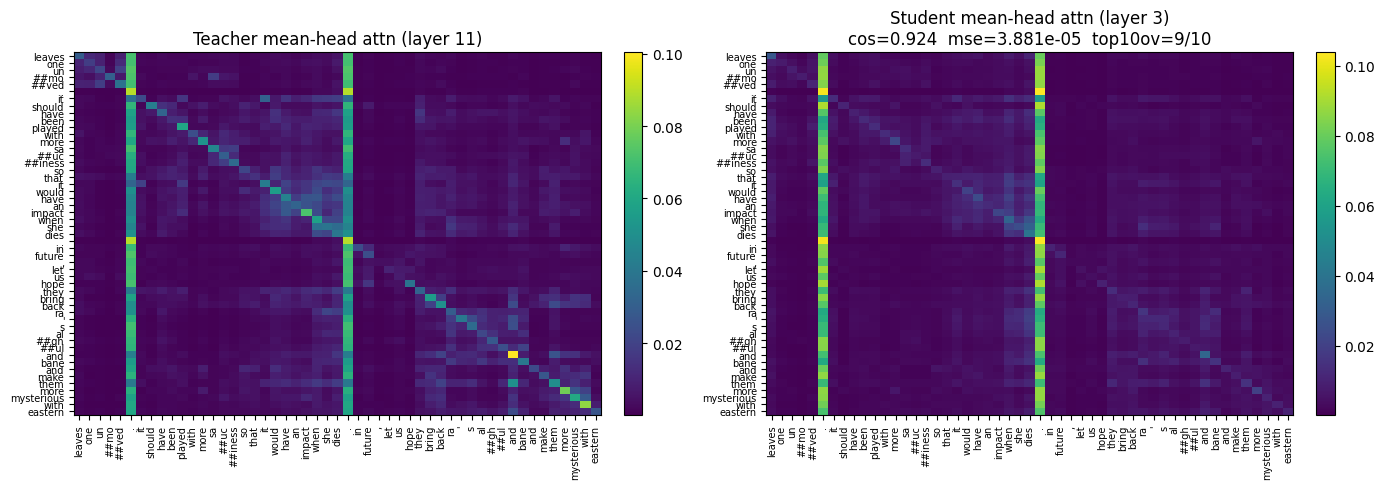

<Figure size 640x480 with 0 Axes>

In [16]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.imshow(sub_T, aspect="auto")
plt.xticks(range(len(sub_tokens)), sub_tokens, rotation=90, fontsize=7)
plt.yticks(range(len(sub_tokens)), sub_tokens, fontsize=7)
plt.title(f"Teacher mean-head attn (layer {t_layer})")
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(1,2,2)
plt.imshow(sub_S, aspect="auto")
plt.xticks(range(len(sub_tokens)), sub_tokens, rotation=90, fontsize=7)
plt.yticks(range(len(sub_tokens)), sub_tokens, fontsize=7)
plt.title(f"Student mean-head attn (layer {s_layer})\ncos={cos:.3f}  mse={mse:.4g}  top{k}ov={overlap}/{k}")
plt.colorbar(fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()
plt.savefig('attn_heatmaps.png')